🔍 Plain Vanilla Mean-Reversion Strategy (In-Sample, Spread 1)
Sharpe Ratio   : 2.1017
Max Drawdown   : 3656.5830
Total Return   : 51951.6404
Win Rate       : 49.79%


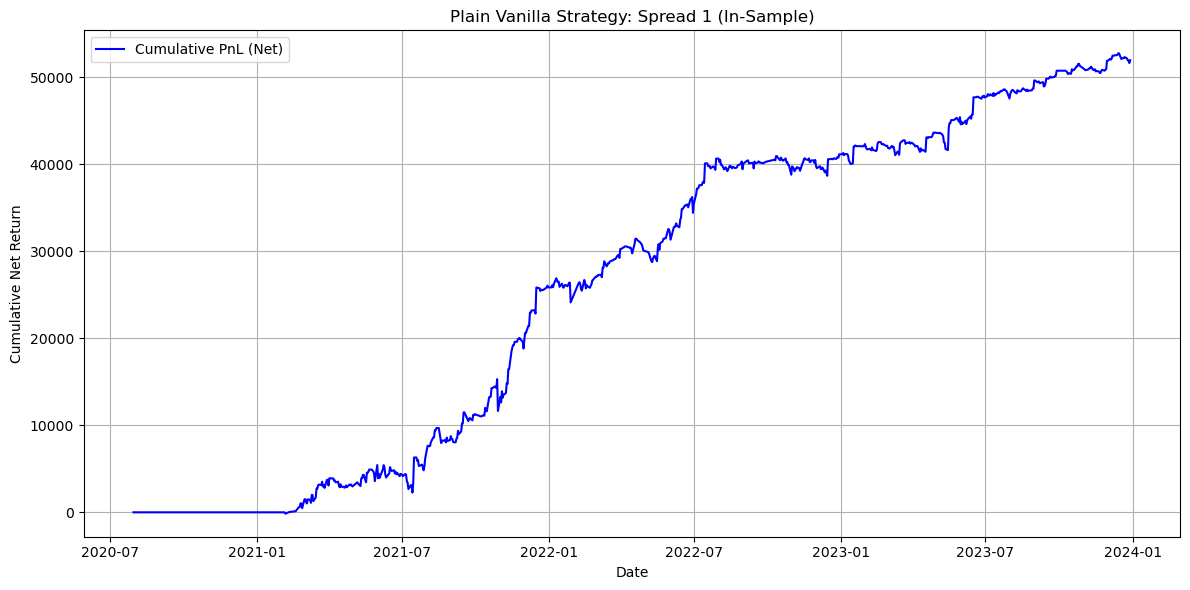

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Step 0: Load data ===
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)
df_coint = df[['HC', 'I', 'J', 'RB']].dropna()

# === Step 1: Slice to In-Sample Data (first 833 observations) ===
df_coint_in_sample = df_coint.iloc[:833]

# === Step 2: Compute Spread 1 using original (unscaled) beta vector ===
beta_1 = np.array([5.00051, 0.6142, 1.56603, -6.57481])
spread_1 = df_coint_in_sample.values @ beta_1
spread_1 = pd.Series(spread_1, index=df_coint_in_sample.index)

# === Step 3: Compute Rolling Mean (for plain vanilla mean-reversion) ===
window = 130
rolling_mean = spread_1.rolling(window=window).mean()
spread_demeaned = spread_1 - rolling_mean

# === Step 4: Generate Trading Signals (Plain Vanilla Logic) ===
position = np.zeros(len(spread_1))

for i in range(1, len(spread_1)):
    # Entry
    if position[i - 1] == 0:
        if spread_demeaned.iloc[i] > 0:
            position[i] = -1  # short spread
        elif spread_demeaned.iloc[i] < 0:
            position[i] = 1   # long spread
        else:
            position[i] = 0
    # Exit
    elif position[i - 1] != 0:
        # If sign of spread changes → exit
        if np.sign(spread_demeaned.iloc[i]) != np.sign(spread_demeaned.iloc[i - 1]):
            position[i] = 0
        else:
            position[i] = position[i - 1]

position = pd.Series(position, index=spread_1.index)

# === Step 5: Compute Strategy Returns ===
spread_return = spread_1.diff().fillna(0)
strategy_returns = position.shift(1) * spread_return

# === Step 6: Apply Transaction Costs ===
transaction_cost = 0.0005  # cost per unit turnover
turnover = position.diff().abs()
costs = turnover * transaction_cost
strategy_returns_net = strategy_returns - costs

# === Step 7: Evaluate Performance (Net of Costs) ===
cumulative_pnl = strategy_returns_net.cumsum()
sharpe_ratio = strategy_returns_net.mean() / strategy_returns_net.std() * np.sqrt(252)
max_drawdown = (cumulative_pnl.cummax() - cumulative_pnl).max()
win_rate = (strategy_returns_net > 0).sum() / (strategy_returns_net != 0).sum()
total_return = cumulative_pnl.iloc[-1]

# === Step 8: Print Results ===
print("🔍 Plain Vanilla Mean-Reversion Strategy (In-Sample, Spread 1)")
print(f"Sharpe Ratio   : {sharpe_ratio:.4f}")
print(f"Max Drawdown   : {max_drawdown:.4f}")
print(f"Total Return   : {total_return:.4f}")
print(f"Win Rate       : {win_rate:.2%}")

# === Step 9: Plot Cumulative PnL (Net of Costs) ===
plt.figure(figsize=(12, 6))
plt.plot(cumulative_pnl, label='Cumulative PnL (Net)', color='blue')
plt.title("Plain Vanilla Strategy: Spread 1 (In-Sample)")
plt.xlabel("Date")
plt.ylabel("Cumulative Net Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


✅ Best Rolling Window: 130
📈 Best Sharpe Ratio  : 2.1017


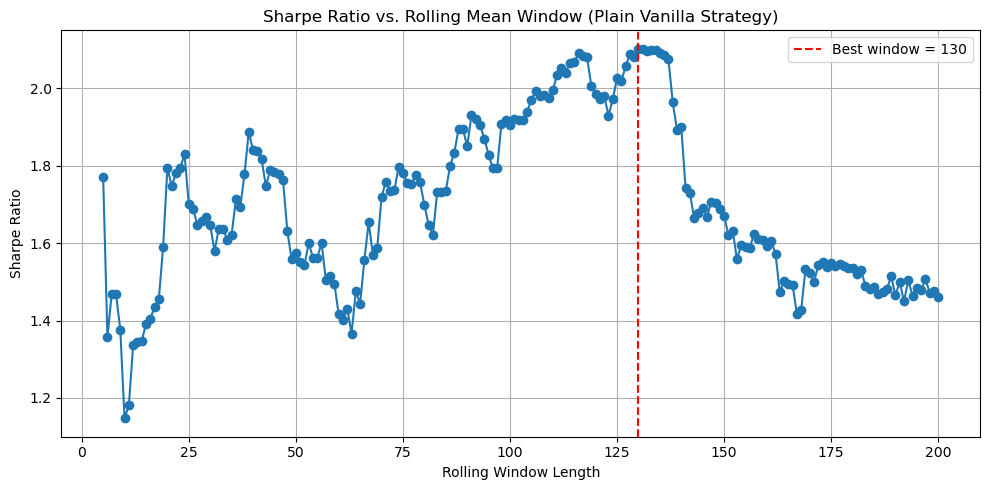

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Step 0: Load data ===
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)
df_coint = df[['HC', 'I', 'J', 'RB']].dropna()
df_coint_in_sample = df_coint.iloc[:833]

# === Step 1: Compute Spread ===
beta_1 = np.array([5.00051, 0.6142, 1.56603, -6.57481])
spread = df_coint_in_sample.values @ beta_1
spread = pd.Series(spread, index=df_coint_in_sample.index)

# === Step 2: Define Evaluation Function ===
def run_strategy(window, spread, cost=0.0005):
    rolling_mean = spread.rolling(window=window).mean()
    spread_demeaned = spread - rolling_mean
    position = np.zeros(len(spread))

    for i in range(1, len(spread)):
        if position[i-1] == 0:
            if spread_demeaned.iloc[i] > 0:
                position[i] = -1
            elif spread_demeaned.iloc[i] < 0:
                position[i] = 1
        elif position[i-1] != 0:
            if np.sign(spread_demeaned.iloc[i]) != np.sign(spread_demeaned.iloc[i-1]):
                position[i] = 0
            else:
                position[i] = position[i-1]

    position = pd.Series(position, index=spread.index)
    spread_return = spread.diff().fillna(0)
    turnover = position.diff().abs()
    strategy_returns = position.shift(1) * spread_return
    cost_per_trade = turnover * cost
    strategy_returns_net = strategy_returns - cost_per_trade

    if strategy_returns_net.std() == 0:
        return -np.inf  # Avoid divide-by-zero errors

    sharpe = strategy_returns_net.mean() / strategy_returns_net.std() * np.sqrt(252)
    return sharpe

# === Step 3: Grid Search over Rolling Windows ===
window_range = range(5, 201, 1)  # Test window = 20, 25, ..., 200
sharpe_by_window = {}

for window in window_range:
    sharpe = run_strategy(window, spread)
    sharpe_by_window[window] = sharpe

# === Step 4: Report Best ===
best_window = max(sharpe_by_window, key=sharpe_by_window.get)
best_sharpe = sharpe_by_window[best_window]

print(f"✅ Best Rolling Window: {best_window}")
print(f"📈 Best Sharpe Ratio  : {best_sharpe:.4f}")

# === Step 5: Plot Sharpe vs. Window ===
plt.figure(figsize=(10, 5))
plt.plot(list(sharpe_by_window.keys()), list(sharpe_by_window.values()), marker='o')
plt.axvline(best_window, color='red', linestyle='--', label=f'Best window = {best_window}')
plt.title("Sharpe Ratio vs. Rolling Mean Window (Plain Vanilla Strategy)")
plt.xlabel("Rolling Window Length")
plt.ylabel("Sharpe Ratio")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


🔍 Plain Vanilla Mean-Reversion Strategy (In-Sample, Spread 1)
Sharpe Ratio   : 1.4473
Max Drawdown   : 1882.8177
Total Return   : 7776.7183
Win Rate       : 50.80%


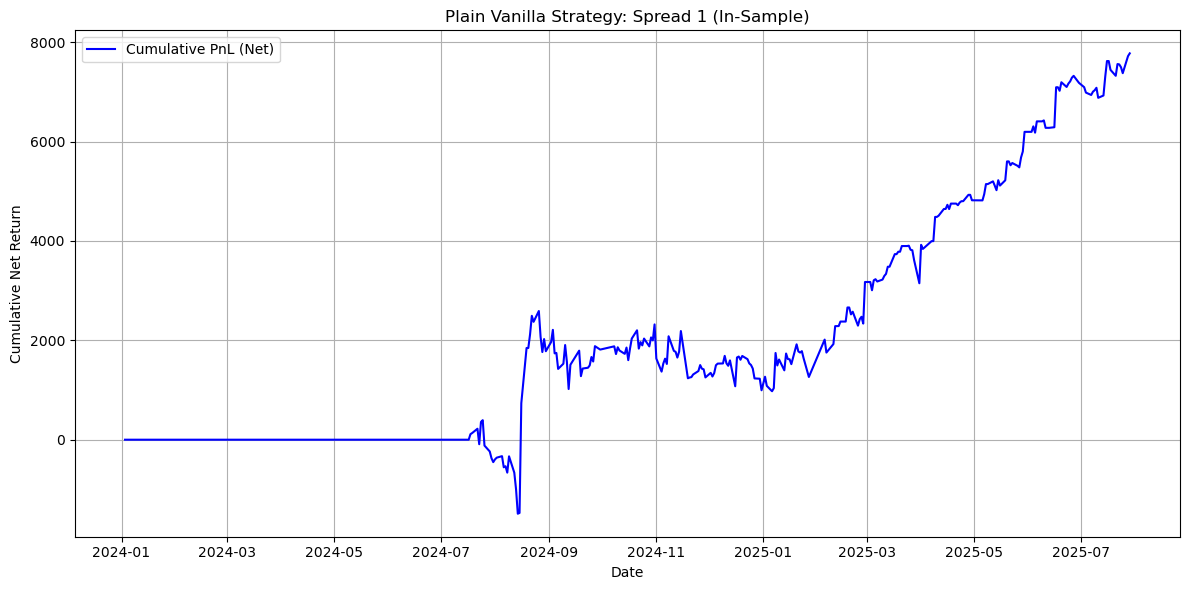

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Step 0: Load data ===
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)
df_coint = df[['HC', 'I', 'J', 'RB']].dropna()

# === Step 1: Slice to In-Sample Data (first 833 observations) ===
df_coint_in_sample = df_coint.iloc[833:]

# === Step 2: Compute Spread 1 using original (unscaled) beta vector ===
beta_1 = np.array([5.00051, 0.6142, 1.56603, -6.57481])
spread_1 = df_coint_in_sample.values @ beta_1
spread_1 = pd.Series(spread_1, index=df_coint_in_sample.index)

# === Step 3: Compute Rolling Mean (for plain vanilla mean-reversion) ===
window = 130
rolling_mean = spread_1.rolling(window=window).mean()
spread_demeaned = spread_1 - rolling_mean

# === Step 4: Generate Trading Signals (Plain Vanilla Logic) ===
position = np.zeros(len(spread_1))

for i in range(1, len(spread_1)):
    # Entry
    if position[i - 1] == 0:
        if spread_demeaned.iloc[i] > 0:
            position[i] = -1  # short spread
        elif spread_demeaned.iloc[i] < 0:
            position[i] = 1   # long spread
        else:
            position[i] = 0
    # Exit
    elif position[i - 1] != 0:
        # If sign of spread changes → exit
        if np.sign(spread_demeaned.iloc[i]) != np.sign(spread_demeaned.iloc[i - 1]):
            position[i] = 0
        else:
            position[i] = position[i - 1]

position = pd.Series(position, index=spread_1.index)

# === Step 5: Compute Strategy Returns ===
spread_return = spread_1.diff().fillna(0)
strategy_returns = position.shift(1) * spread_return

# === Step 6: Apply Transaction Costs ===
transaction_cost = 0.0005  # cost per unit turnover
turnover = position.diff().abs()
costs = turnover * transaction_cost
strategy_returns_net = strategy_returns - costs

# === Step 7: Evaluate Performance (Net of Costs) ===
cumulative_pnl = strategy_returns_net.cumsum()
sharpe_ratio = strategy_returns_net.mean() / strategy_returns_net.std() * np.sqrt(252)
max_drawdown = (cumulative_pnl.cummax() - cumulative_pnl).max()
win_rate = (strategy_returns_net > 0).sum() / (strategy_returns_net != 0).sum()
total_return = cumulative_pnl.iloc[-1]

# === Step 8: Print Results ===
print("🔍 Plain Vanilla Mean-Reversion Strategy (In-Sample, Spread 1)")
print(f"Sharpe Ratio   : {sharpe_ratio:.4f}")
print(f"Max Drawdown   : {max_drawdown:.4f}")
print(f"Total Return   : {total_return:.4f}")
print(f"Win Rate       : {win_rate:.2%}")

# === Step 9: Plot Cumulative PnL (Net of Costs) ===
plt.figure(figsize=(12, 6))
plt.plot(cumulative_pnl, label='Cumulative PnL (Net)', color='blue')
plt.title("Plain Vanilla Strategy: Spread 1 (In-Sample)")
plt.xlabel("Date")
plt.ylabel("Cumulative Net Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


✅ Excel saved: Plain Vanilla Strategy with Integer Hands.xlsx

🔍 Plain Vanilla Mean-Reversion Strategy (All Data, Integer Hands)
Initial Capital Deployed: 0.00 RMB
Final Cumulative Profit: 35,791,343.95 RMB
Profit Rate: inf%
Sharpe Ratio: 1.0933
Max Drawdown: 4,166,494.25
Win Rate: 49.77%


C:\Users\chris\AppData\Local\Temp\ipykernel_36860\2088390914.py:114: RuntimeWarning: divide by zero encountered in scalar divide
  profit_rate = final_profit / initial_capital


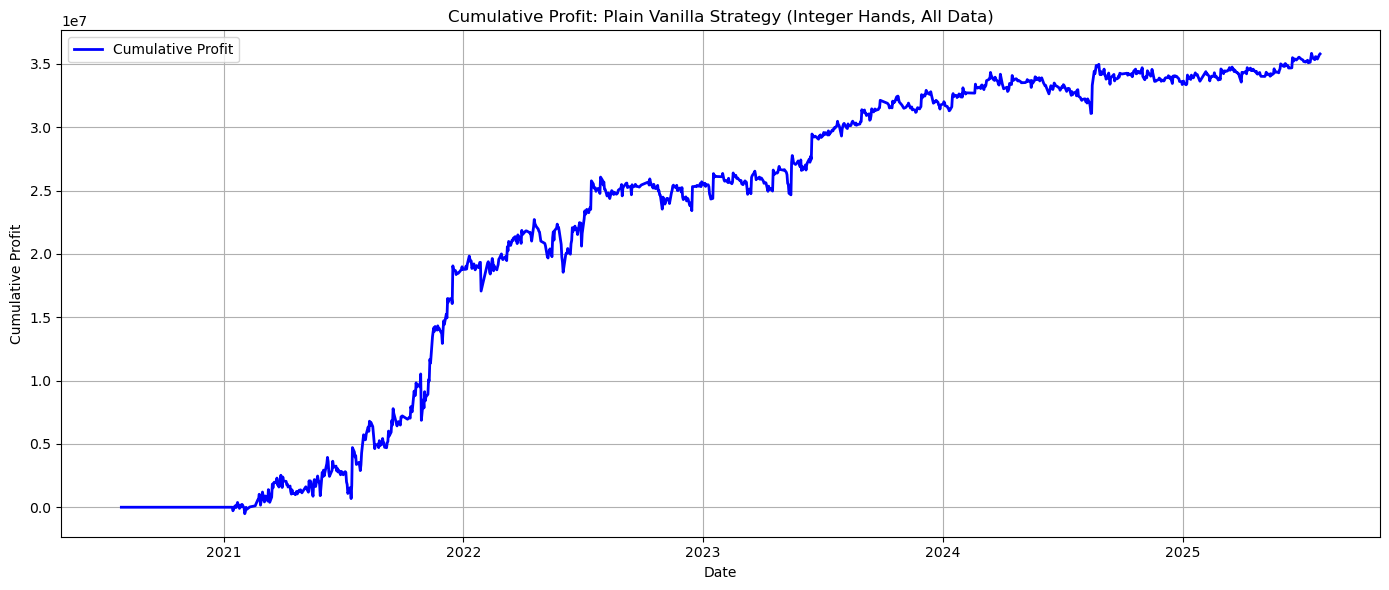

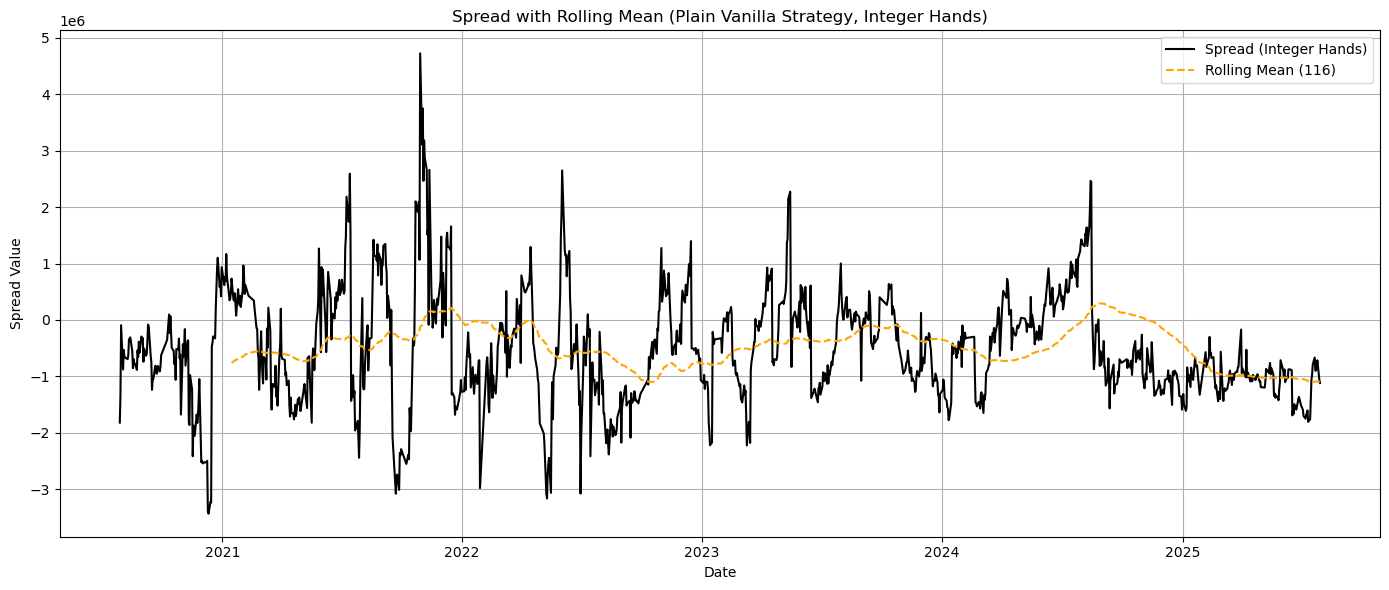

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Step 0: Load data ===
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)
df_coint = df[['HC', 'I', 'J', 'RB']].dropna()
df_coint_full = df_coint

# === Step 1: Original beta and contract sizes ===
original_beta = {'HC': 5.00051, 'I': 0.6142, 'J': 1.56603, 'RB': -6.57481}
contract_sizes = {'HC': 10, 'I': 100, 'J': 100, 'RB': 10}

# === Step 2: Scale to integer hands ===
scaling_factor = 1000
scaled_beta = {k: original_beta[k] * scaling_factor for k in original_beta}
scaled_hands = {k: round(scaled_beta[k] / contract_sizes[k]) for k in scaled_beta}

# Final beta vector using integer hands × contract size
beta_1 = np.array([
    scaled_hands['HC'] * contract_sizes['HC'],
    scaled_hands['I']  * contract_sizes['I'],
    scaled_hands['J']  * contract_sizes['J'],
    scaled_hands['RB'] * contract_sizes['RB']
])

# === Step 3: Compute Spread ===
spread_1 = df_coint_full[['HC', 'I', 'J', 'RB']].values @ beta_1
spread_1 = pd.Series(spread_1, index=df_coint_full.index)

# === Step 4: Plain Vanilla Signal Generation ===
window = 116
rolling_mean = spread_1.rolling(window=window).mean()
spread_demeaned = spread_1 - rolling_mean

position = np.zeros(len(spread_1))
for i in range(1, len(spread_1)):
    if position[i - 1] == 0:
        if spread_demeaned.iloc[i] > 0:
            position[i] = -1
        elif spread_demeaned.iloc[i] < 0:
            position[i] = 1
    else:
        if np.sign(spread_demeaned.iloc[i]) != np.sign(spread_demeaned.iloc[i - 1]):
            position[i] = 0
        else:
            position[i] = position[i - 1]

position = pd.Series(position, index=spread_1.index)

# === Step 5: PnL and Exposure Calculation ===
transaction_fee_rate = 0.005

daily_profit = [0]
cumulative_profit = [0]
gross_exposure = []
net_exposure = []
position_type = []
position_details = []

first_day_details = {k: 0 for k in ['HC', 'I', 'J', 'RB']}
position_details.append(first_day_details)
gross_exposure.append(0)
net_exposure.append(0)
position_type.append("None")

for i in range(1, len(df_coint_full)):
    prices = df_coint_full.iloc[i]
    pos_yesterday = position.iloc[i - 1]
    pos_today = position.iloc[i]

    # Exposure per asset
    value_dict = {}
    for k in ['HC', 'I', 'J', 'RB']:
        hands = scaled_hands[k]
        size = contract_sizes[k]
        price = prices[k]
        notional = pos_today * hands * size * price
        value_dict[k] = notional
    total_gross = sum(abs(v) for v in value_dict.values())
    total_net = abs(sum(value_dict.values()))

    # PnL
    spread_change = spread_1.iloc[i] - spread_1.iloc[i - 1]
    profit = spread_change * pos_yesterday

    if pos_today != pos_yesterday:
        profit -= transaction_fee_rate * total_gross

    daily_profit.append(profit)
    cumulative_profit.append(cumulative_profit[-1] + profit)
    gross_exposure.append(total_gross)
    net_exposure.append(total_net)
    position_details.append(value_dict)
    position_type.append("Long" if pos_today == 1 else "Short" if pos_today == -1 else "None")

# === Step 6: Save to Excel ===
exposure_df = pd.DataFrame({
    'Position': position_type,
    'Gross Exposure': gross_exposure,
    'Net Exposure': net_exposure,
    'Daily Profit': daily_profit,
    'Cumulative Profit': cumulative_profit
}, index=df_coint_full.index)

positions_df = pd.DataFrame(position_details, index=df_coint_full.index)
output_df = pd.concat([exposure_df, positions_df], axis=1)
output_df.to_excel("Plain Vanilla Strategy with Integer Hands.xlsx")
print("✅ Excel saved: Plain Vanilla Strategy with Integer Hands.xlsx")

# === Step 7: Performance Summary ===
initial_capital = gross_exposure[1]
final_profit = cumulative_profit[-1]
profit_rate = final_profit / initial_capital
daily_returns = pd.Series(daily_profit[1:], index=df_coint_full.index[1:])
sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252)
max_drawdown = (pd.Series(cumulative_profit, index=df_coint_full.index).cummax() - pd.Series(cumulative_profit, index=df_coint_full.index)).max()
win_rate = (daily_returns > 0).sum() / (daily_returns != 0).sum()

print("\n🔍 Plain Vanilla Mean-Reversion Strategy (All Data, Integer Hands)")
print(f"Initial Capital Deployed: {initial_capital:,.2f} RMB")
print(f"Final Cumulative Profit: {final_profit:,.2f} RMB")
print(f"Profit Rate: {profit_rate:.2%}")
print(f"Sharpe Ratio: {sharpe:.4f}")
print(f"Max Drawdown: {max_drawdown:,.2f}")
print(f"Win Rate: {win_rate:.2%}")

# === Step 8: Plot Cumulative Profit ===
plt.figure(figsize=(14, 6))
plt.plot(df_coint_full.index, cumulative_profit, label='Cumulative Profit', color='blue', linewidth=2)
plt.title("Cumulative Profit: Plain Vanilla Strategy (Integer Hands, All Data)")
plt.xlabel("Date")
plt.ylabel("Cumulative Profit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Step 9: Plot Spread and Rolling Mean ===
plt.figure(figsize=(14, 6))
plt.plot(spread_1, label='Spread (Integer Hands)', color='black')
plt.plot(rolling_mean, label='Rolling Mean (116)', linestyle='--', color='orange')
plt.title("Spread with Rolling Mean (Plain Vanilla Strategy, Integer Hands)")
plt.xlabel("Date")
plt.ylabel("Spread Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


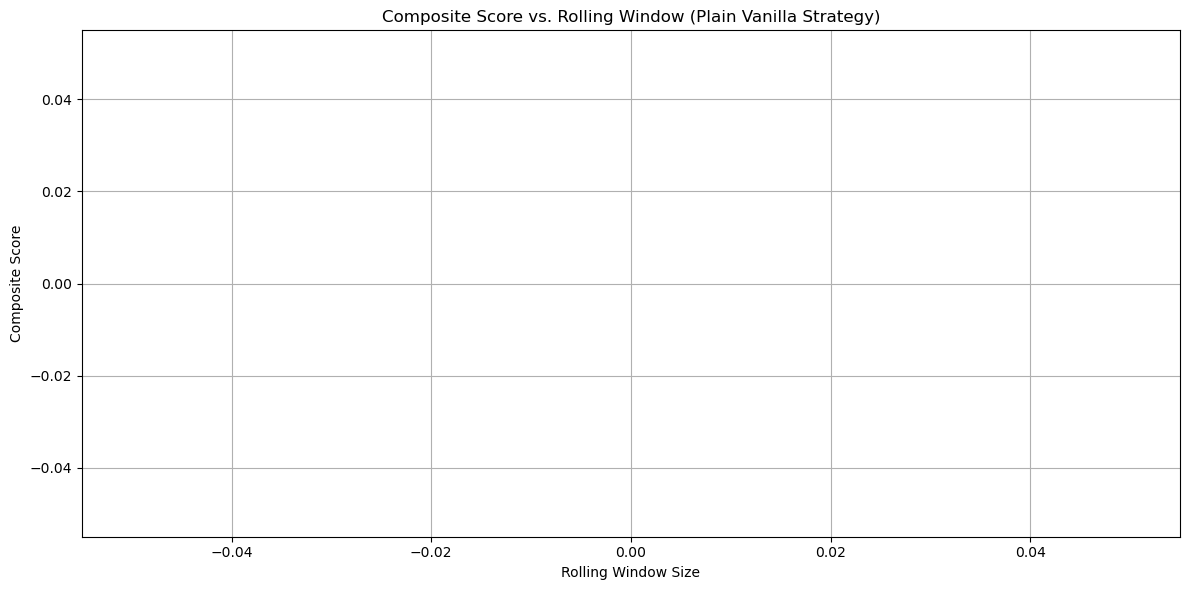

✅ Saved: Plain_Vanilla_composite_score_data_1.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Step 0: Load data ===
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)
df_coint = df[['HC', 'I', 'J', 'RB']].dropna()
df_coint_full = df_coint

# === Step 1: Original beta and contract sizes ===
original_beta = {'HC': 5.00051, 'I': 0.6142, 'J': 1.56603, 'RB': -6.57481}
contract_sizes = {'HC': 10, 'I': 100, 'J': 100, 'RB': 10}
scaling_factor = 1000
scaled_hands = {k: round(original_beta[k] * scaling_factor / contract_sizes[k]) for k in original_beta}
beta_1 = np.array([scaled_hands[k] * contract_sizes[k] for k in ['HC', 'I', 'J', 'RB']])

# === Step 2: Spread ===
spread_1 = df_coint_full[['HC', 'I', 'J', 'RB']].values @ beta_1
spread_1 = pd.Series(spread_1, index=df_coint_full.index)

# === Step 3: Loop over windows ===
results = []
transaction_fee_rate = 0.005

for window in range(30, 151):
    rolling_mean = spread_1.rolling(window=window).mean()
    spread_demeaned = spread_1 - rolling_mean

    position = np.zeros(len(spread_1))
    trade_entries = []
    current_holding = 0
    in_position = False

    for i in range(1, len(spread_1)):
        if position[i - 1] == 0:
            if spread_demeaned.iloc[i] > 0:
                position[i] = -1
                trade_entries.append(i)
                in_position = True
                current_holding = 1
            elif spread_demeaned.iloc[i] < 0:
                position[i] = 1
                trade_entries.append(i)
                in_position = True
                current_holding = 1
        else:
            if np.sign(spread_demeaned.iloc[i]) != np.sign(spread_demeaned.iloc[i - 1]):
                position[i] = 0
                in_position = False
                if current_holding > 0:
                    trade_entries[-1] = current_holding  # replace entry index with holding time
                current_holding = 0
            else:
                position[i] = position[i - 1]
                if in_position:
                    current_holding += 1

    position = pd.Series(position, index=spread_1.index)

    # Final cleanup for last holding
    if in_position and current_holding > 0:
        trade_entries[-1] = current_holding

    num_trades = len([x for x in trade_entries if isinstance(x, int) == False])
    avg_holding = np.mean([x for x in trade_entries if isinstance(x, int) == False]) if num_trades > 0 else 0

    # === PnL & Metrics ===
    daily_profit = [0]
    cumulative_profit = [0]
    wins = 0
    losses = 0

    for i in range(1, len(df_coint_full)):
        prices = df_coint_full.iloc[i]
        pos_yesterday = position.iloc[i - 1]
        pos_today = position.iloc[i]

        spread_change = spread_1.iloc[i] - spread_1.iloc[i - 1]
        profit = spread_change * pos_yesterday

        value_dict = {k: pos_today * scaled_hands[k] * contract_sizes[k] * prices[k] for k in ['HC', 'I', 'J', 'RB']}
        total_gross = sum(abs(v) for v in value_dict.values())

        if pos_today != pos_yesterday:
            profit -= transaction_fee_rate * total_gross

        daily_profit.append(profit)
        cumulative_profit.append(cumulative_profit[-1] + profit)
        if profit > 0:
            wins += 1
        elif profit < 0:
            losses += 1

    daily_returns = pd.Series(daily_profit[1:], index=df_coint_full.index[1:])
    sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252) if daily_returns.std() != 0 else 0
    max_drawdown = (pd.Series(cumulative_profit).cummax() - pd.Series(cumulative_profit)).max()
    win_rate = wins / (wins + losses) if (wins + losses) > 0 else 0

    results.append({
        'Window': window,
        'Sharpe': sharpe,
        'Max Drawdown': max_drawdown,
        'Win Rate': win_rate,
        'Trades': num_trades,
        'Holding Time': avg_holding
    })

# === Step 4: Normalize & Score ===
metrics_df = pd.DataFrame(results)

def normalize(series, higher_is_better=True):
    norm = (series - series.min()) / (series.max() - series.min())
    return norm if higher_is_better else 1 - norm

metrics_df['Sharpe_N'] = normalize(metrics_df['Sharpe'])
metrics_df['MDD_N'] = normalize(metrics_df['Max Drawdown'], higher_is_better=False)
metrics_df['WinRate_N'] = normalize(metrics_df['Win Rate'])
metrics_df['Trades_N'] = normalize(metrics_df['Trades'])
metrics_df['Holding_N'] = normalize(metrics_df['Holding Time'], higher_is_better=False)

metrics_df['Score'] = (
    0.30 * metrics_df['Sharpe_N'] +
    0.10 * metrics_df['MDD_N'] +
    0.20 * metrics_df['WinRate_N'] +
    0.20 * metrics_df['Trades_N'] +
    0.20 * metrics_df['Holding_N']
)

# === Step 5: Plot Composite Score ===
plt.figure(figsize=(12, 6))
plt.plot(metrics_df['Window'], metrics_df['Score'], marker='o', linewidth=2)
plt.title("Composite Score vs. Rolling Window (Plain Vanilla Strategy)")
plt.xlabel("Rolling Window Size")
plt.ylabel("Composite Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 6: Save to Excel ===
metrics_df.to_excel("Plain_Vanilla_composite_score_data_1.xlsx", index=False)
print("✅ Saved: Plain_Vanilla_composite_score_data_1.xlsx")


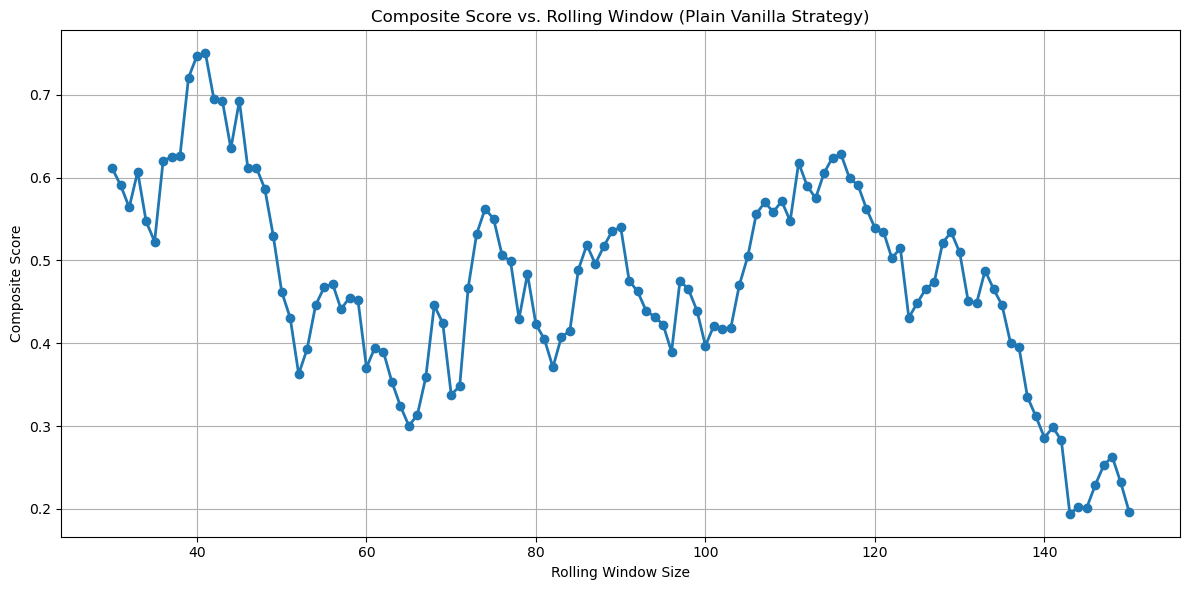

✅ Saved: Plain_Vanilla_composite_score_data_40%.xlsx


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Step 0: Load data ===
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)
df_coint = df[['HC', 'I', 'J', 'RB']].dropna()
df_coint_full = df_coint

# === Step 1: Original beta and contract sizes ===
original_beta = {'HC': 5.00051, 'I': 0.6142, 'J': 1.56603, 'RB': -6.57481}
contract_sizes = {'HC': 10, 'I': 100, 'J': 100, 'RB': 10}
scaling_factor = 1000
scaled_hands = {k: round(original_beta[k] * scaling_factor / contract_sizes[k]) for k in original_beta}
beta_1 = np.array([scaled_hands[k] * contract_sizes[k] for k in ['HC', 'I', 'J', 'RB']])

# === Step 2: Spread ===
spread_1 = df_coint_full[['HC', 'I', 'J', 'RB']].values @ beta_1
spread_1 = pd.Series(spread_1, index=df_coint_full.index)

# === Step 3: Loop over windows ===
results = []
transaction_fee_rate = 0.005

for window in range(30, 151):
    rolling_mean = spread_1.rolling(window=window).mean()
    spread_demeaned = spread_1 - rolling_mean

    position = np.zeros(len(spread_1))
    holding_times = []
    current_holding = 0
    in_position = False
    num_trades = 0

    for i in range(1, len(spread_1)):
        if position[i - 1] == 0:
            if spread_demeaned.iloc[i] > 0:
                position[i] = -1
                in_position = True
                current_holding = 1
                num_trades += 1
            elif spread_demeaned.iloc[i] < 0:
                position[i] = 1
                in_position = True
                current_holding = 1
                num_trades += 1
        else:
            if np.sign(spread_demeaned.iloc[i]) != np.sign(spread_demeaned.iloc[i - 1]):
                position[i] = 0
                in_position = False
                holding_times.append(current_holding)
                current_holding = 0
            else:
                position[i] = position[i - 1]
                if in_position:
                    current_holding += 1

    # Final open position
    if in_position and current_holding > 0:
        holding_times.append(current_holding)

    avg_holding = np.mean(holding_times) if holding_times else 0

    # === PnL & Metrics ===
    daily_profit = [0]
    cumulative_profit = [0]
    wins = 0
    losses = 0

    for i in range(1, len(df_coint_full)):
        prices = df_coint_full.iloc[i]
        pos_yesterday = position[i - 1]
        pos_today = position[i]

        spread_change = spread_1.iloc[i] - spread_1.iloc[i - 1]
        profit = spread_change * pos_yesterday

        value_dict = {k: pos_today * scaled_hands[k] * contract_sizes[k] * prices[k] for k in ['HC', 'I', 'J', 'RB']}
        total_gross = sum(abs(v) for v in value_dict.values())

        if pos_today != pos_yesterday:
            profit -= transaction_fee_rate * total_gross

        daily_profit.append(profit)
        cumulative_profit.append(cumulative_profit[-1] + profit)

        if profit > 0:
            wins += 1
        elif profit < 0:
            losses += 1

    daily_returns = pd.Series(daily_profit[1:], index=df_coint_full.index[1:])
    sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252) if daily_returns.std() != 0 else 0
    max_drawdown = (pd.Series(cumulative_profit).cummax() - pd.Series(cumulative_profit)).max()
    win_rate = wins / (wins + losses) if (wins + losses) > 0 else 0

    results.append({
        'Window': window,
        'Sharpe': sharpe,
        'Max Drawdown': max_drawdown,
        'Win Rate': win_rate,
        'Trades': num_trades,
        'Holding Time': avg_holding
    })

# === Step 4: Normalize & Score ===
metrics_df = pd.DataFrame(results)

def normalize(series, higher_is_better=True):
    norm = (series - series.min()) / (series.max() - series.min())
    return norm if higher_is_better else 1 - norm

metrics_df['Sharpe_N'] = normalize(metrics_df['Sharpe'])
metrics_df['MDD_N'] = normalize(metrics_df['Max Drawdown'], higher_is_better=False)
metrics_df['WinRate_N'] = normalize(metrics_df['Win Rate'])
metrics_df['Trades_N'] = normalize(metrics_df['Trades'])
metrics_df['Holding_N'] = normalize(metrics_df['Holding Time'], higher_is_better=False)

metrics_df['Score'] = (
    0.20 * metrics_df['Sharpe_N'] +
    0.10 * metrics_df['MDD_N'] +
    0.10 * metrics_df['WinRate_N'] +
    0.35 * metrics_df['Trades_N'] +
    0.25 * metrics_df['Holding_N']
)

# === Step 5: Plot Composite Score ===
plt.figure(figsize=(12, 6))
plt.plot(metrics_df['Window'], metrics_df['Score'], marker='o', linewidth=2)
plt.title("Composite Score vs. Rolling Window (Plain Vanilla Strategy)")
plt.xlabel("Rolling Window Size")
plt.ylabel("Composite Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 6: Save to Excel ===
metrics_df.to_excel("Plain_Vanilla_composite_score_data_40%.xlsx", index=False)
print("✅ Saved: Plain_Vanilla_composite_score_data_40%.xlsx")


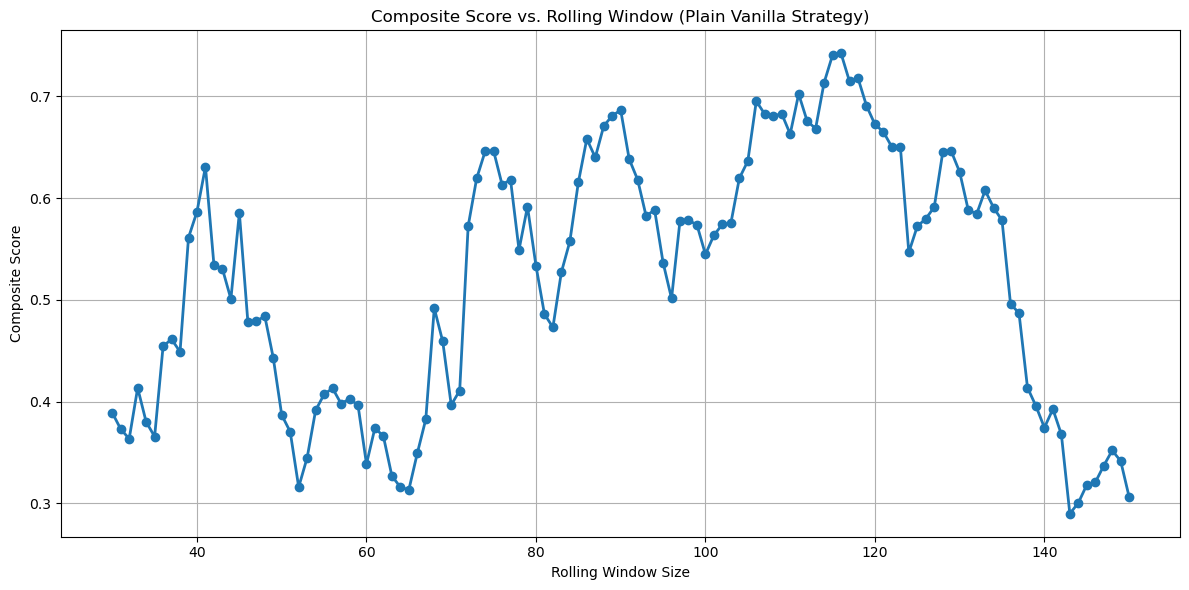

✅ Saved: Plain_Vanilla_composite_score_data_65%.xlsx


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Step 0: Load data ===
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)
df_coint = df[['HC', 'I', 'J', 'RB']].dropna()
df_coint_full = df_coint

# === Step 1: Original beta and contract sizes ===
original_beta = {'HC': 5.00051, 'I': 0.6142, 'J': 1.56603, 'RB': -6.57481}
contract_sizes = {'HC': 10, 'I': 100, 'J': 100, 'RB': 10}
scaling_factor = 1000
scaled_hands = {k: round(original_beta[k] * scaling_factor / contract_sizes[k]) for k in original_beta}
beta_1 = np.array([scaled_hands[k] * contract_sizes[k] for k in ['HC', 'I', 'J', 'RB']])

# === Step 2: Spread ===
spread_1 = df_coint_full[['HC', 'I', 'J', 'RB']].values @ beta_1
spread_1 = pd.Series(spread_1, index=df_coint_full.index)

# === Step 3: Loop over windows ===
results = []
transaction_fee_rate = 0.005

for window in range(30, 151):
    rolling_mean = spread_1.rolling(window=window).mean()
    spread_demeaned = spread_1 - rolling_mean

    position = np.zeros(len(spread_1))
    holding_times = []
    current_holding = 0
    in_position = False
    num_trades = 0

    for i in range(1, len(spread_1)):
        if position[i - 1] == 0:
            if spread_demeaned.iloc[i] > 0:
                position[i] = -1
                in_position = True
                current_holding = 1
                num_trades += 1
            elif spread_demeaned.iloc[i] < 0:
                position[i] = 1
                in_position = True
                current_holding = 1
                num_trades += 1
        else:
            if np.sign(spread_demeaned.iloc[i]) != np.sign(spread_demeaned.iloc[i - 1]):
                position[i] = 0
                in_position = False
                holding_times.append(current_holding)
                current_holding = 0
            else:
                position[i] = position[i - 1]
                if in_position:
                    current_holding += 1

    # Final open position
    if in_position and current_holding > 0:
        holding_times.append(current_holding)

    avg_holding = np.mean(holding_times) if holding_times else 0

    # === PnL & Metrics ===
    daily_profit = [0]
    cumulative_profit = [0]
    wins = 0
    losses = 0

    for i in range(1, len(df_coint_full)):
        prices = df_coint_full.iloc[i]
        pos_yesterday = position[i - 1]
        pos_today = position[i]

        spread_change = spread_1.iloc[i] - spread_1.iloc[i - 1]
        profit = spread_change * pos_yesterday

        value_dict = {k: pos_today * scaled_hands[k] * contract_sizes[k] * prices[k] for k in ['HC', 'I', 'J', 'RB']}
        total_gross = sum(abs(v) for v in value_dict.values())

        if pos_today != pos_yesterday:
            profit -= transaction_fee_rate * total_gross

        daily_profit.append(profit)
        cumulative_profit.append(cumulative_profit[-1] + profit)

        if profit > 0:
            wins += 1
        elif profit < 0:
            losses += 1

    daily_returns = pd.Series(daily_profit[1:], index=df_coint_full.index[1:])
    sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252) if daily_returns.std() != 0 else 0
    max_drawdown = (pd.Series(cumulative_profit).cummax() - pd.Series(cumulative_profit)).max()
    win_rate = wins / (wins + losses) if (wins + losses) > 0 else 0

    results.append({
        'Window': window,
        'Sharpe': sharpe,
        'Max Drawdown': max_drawdown,
        'Win Rate': win_rate,
        'Trades': num_trades,
        'Holding Time': avg_holding
    })

# === Step 4: Normalize & Score ===
metrics_df = pd.DataFrame(results)

def normalize(series, higher_is_better=True):
    norm = (series - series.min()) / (series.max() - series.min())
    return norm if higher_is_better else 1 - norm

metrics_df['Sharpe_N'] = normalize(metrics_df['Sharpe'])
metrics_df['MDD_N'] = normalize(metrics_df['Max Drawdown'], higher_is_better=False)
metrics_df['WinRate_N'] = normalize(metrics_df['Win Rate'])
metrics_df['Trades_N'] = normalize(metrics_df['Trades'])
metrics_df['Holding_N'] = normalize(metrics_df['Holding Time'], higher_is_better=False)

metrics_df['Score'] = (
    0.30 * metrics_df['Sharpe_N'] +
    0.20 * metrics_df['MDD_N'] +
    0.15 * metrics_df['WinRate_N'] +
    0.20 * metrics_df['Trades_N'] +
    0.15 * metrics_df['Holding_N']
)

# === Step 5: Plot Composite Score ===
plt.figure(figsize=(12, 6))
plt.plot(metrics_df['Window'], metrics_df['Score'], marker='o', linewidth=2)
plt.title("Composite Score vs. Rolling Window (Plain Vanilla Strategy)")
plt.xlabel("Rolling Window Size")
plt.ylabel("Composite Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 6: Save to Excel ===
metrics_df.to_excel("Plain_Vanilla_composite_score_data_65%.xlsx", index=False)
print("✅ Saved: Plain_Vanilla_composite_score_data_65%.xlsx")


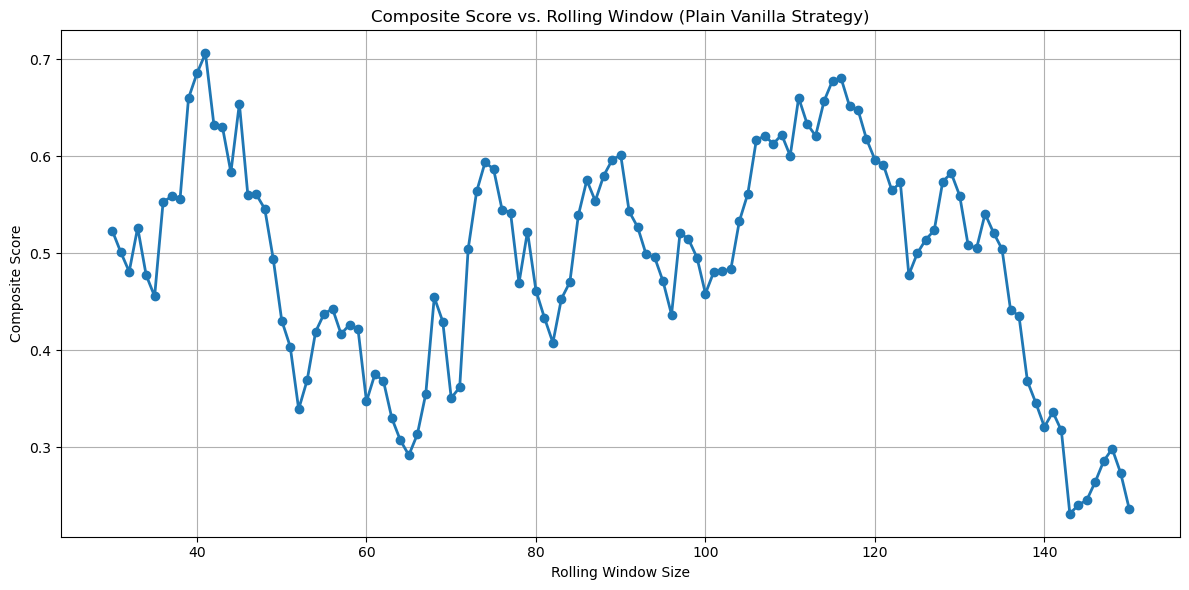

✅ Saved: Plain_Vanilla_composite_score_data_50%.xlsx


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Step 0: Load data ===
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)
df_coint = df[['HC', 'I', 'J', 'RB']].dropna()
df_coint_full = df_coint

# === Step 1: Original beta and contract sizes ===
original_beta = {'HC': 5.00051, 'I': 0.6142, 'J': 1.56603, 'RB': -6.57481}
contract_sizes = {'HC': 10, 'I': 100, 'J': 100, 'RB': 10}
scaling_factor = 1000
scaled_hands = {k: round(original_beta[k] * scaling_factor / contract_sizes[k]) for k in original_beta}
beta_1 = np.array([scaled_hands[k] * contract_sizes[k] for k in ['HC', 'I', 'J', 'RB']])

# === Step 2: Spread ===
spread_1 = df_coint_full[['HC', 'I', 'J', 'RB']].values @ beta_1
spread_1 = pd.Series(spread_1, index=df_coint_full.index)

# === Step 3: Loop over windows ===
results = []
transaction_fee_rate = 0.005

for window in range(30, 151):
    rolling_mean = spread_1.rolling(window=window).mean()
    spread_demeaned = spread_1 - rolling_mean

    position = np.zeros(len(spread_1))
    holding_times = []
    current_holding = 0
    in_position = False
    num_trades = 0

    for i in range(1, len(spread_1)):
        if position[i - 1] == 0:
            if spread_demeaned.iloc[i] > 0:
                position[i] = -1
                in_position = True
                current_holding = 1
                num_trades += 1
            elif spread_demeaned.iloc[i] < 0:
                position[i] = 1
                in_position = True
                current_holding = 1
                num_trades += 1
        else:
            if np.sign(spread_demeaned.iloc[i]) != np.sign(spread_demeaned.iloc[i - 1]):
                position[i] = 0
                in_position = False
                holding_times.append(current_holding)
                current_holding = 0
            else:
                position[i] = position[i - 1]
                if in_position:
                    current_holding += 1

    # Final open position
    if in_position and current_holding > 0:
        holding_times.append(current_holding)

    avg_holding = np.mean(holding_times) if holding_times else 0

    # === PnL & Metrics ===
    daily_profit = [0]
    cumulative_profit = [0]
    wins = 0
    losses = 0

    for i in range(1, len(df_coint_full)):
        prices = df_coint_full.iloc[i]
        pos_yesterday = position[i - 1]
        pos_today = position[i]

        spread_change = spread_1.iloc[i] - spread_1.iloc[i - 1]
        profit = spread_change * pos_yesterday

        value_dict = {k: pos_today * scaled_hands[k] * contract_sizes[k] * prices[k] for k in ['HC', 'I', 'J', 'RB']}
        total_gross = sum(abs(v) for v in value_dict.values())

        if pos_today != pos_yesterday:
            profit -= transaction_fee_rate * total_gross

        daily_profit.append(profit)
        cumulative_profit.append(cumulative_profit[-1] + profit)

        if profit > 0:
            wins += 1
        elif profit < 0:
            losses += 1

    daily_returns = pd.Series(daily_profit[1:], index=df_coint_full.index[1:])
    sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252) if daily_returns.std() != 0 else 0
    max_drawdown = (pd.Series(cumulative_profit).cummax() - pd.Series(cumulative_profit)).max()
    win_rate = wins / (wins + losses) if (wins + losses) > 0 else 0

    results.append({
        'Window': window,
        'Sharpe': sharpe,
        'Max Drawdown': max_drawdown,
        'Win Rate': win_rate,
        'Trades': num_trades,
        'Holding Time': avg_holding
    })

# === Step 4: Normalize & Score ===
metrics_df = pd.DataFrame(results)

def normalize(series, higher_is_better=True):
    norm = (series - series.min()) / (series.max() - series.min())
    return norm if higher_is_better else 1 - norm

metrics_df['Sharpe_N'] = normalize(metrics_df['Sharpe'])
metrics_df['MDD_N'] = normalize(metrics_df['Max Drawdown'], higher_is_better=False)
metrics_df['WinRate_N'] = normalize(metrics_df['Win Rate'])
metrics_df['Trades_N'] = normalize(metrics_df['Trades'])
metrics_df['Holding_N'] = normalize(metrics_df['Holding Time'], higher_is_better=False)

metrics_df['Score'] = (
    0.25 * metrics_df['Sharpe_N'] +
    0.15 * metrics_df['MDD_N'] +
    0.10 * metrics_df['WinRate_N'] +
    0.25 * metrics_df['Trades_N'] +
    0.25 * metrics_df['Holding_N']
)

# === Step 5: Plot Composite Score ===
plt.figure(figsize=(12, 6))
plt.plot(metrics_df['Window'], metrics_df['Score'], marker='o', linewidth=2)
plt.title("Composite Score vs. Rolling Window (Plain Vanilla Strategy)")
plt.xlabel("Rolling Window Size")
plt.ylabel("Composite Score")
plt.grid(True)
plt.tight_layout()
plt.show()

# === Step 6: Save to Excel ===
metrics_df.to_excel("Plain_Vanilla_composite_score_data_50%.xlsx", index=False)
print("✅ Saved: Plain_Vanilla_composite_score_data_50%.xlsx")


In [1]:
import pandas as pd
from pathlib import Path

# --- Inputs ---
FILE = Path("Plain Vanilla Strategy with Integer Hands.xlsx")  # same folder as notebook
DATE_COL = "date"
DAILY_PNL_COL = "Daily Profit"          # E in your screenshot
GROSS_EXPO_COL = "Gross Exposure"       # C in your screenshot
START = pd.Timestamp("2024-01-01")
END   = pd.Timestamp("2025-07-29")      # inclusive

# --- Load ---
df = pd.read_excel(FILE)
# Normalize column names just in case of stray spaces/case
df.columns = [str(c).strip() for c in df.columns]

# Parse dates
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

# --- Filter the period (inclusive) ---
mask = (df[DATE_COL] >= START) & (df[DATE_COL] <= END)
df_period = df.loc[mask, [DATE_COL, DAILY_PNL_COL, GROSS_EXPO_COL]].copy()

if df_period.empty:
    raise ValueError("No rows found in the requested date range.")

# --- Compute Cumulative Profit over the period ---
# Using Daily Profit sum avoids any ambiguities with a running 'Cumulative Profit' column.
cumulative_profit = df_period[DAILY_PNL_COL].sum()

# --- Average Gross Exposure over the period ---
# Simple time-average (includes zeros on flat days, which is usually what you want)
avg_gross_exposure = df_period[GROSS_EXPO_COL].mean()

# --- Annual Return (as defined by you) ---
if avg_gross_exposure == 0:
    annual_return = float('nan')
    note = "Average gross exposure is 0; cannot compute the ratio."
else:
    annual_return = cumulative_profit / avg_gross_exposure
    note = ""

print(f"Period: {START.date()} to {END.date()} (inclusive)")
print(f"Rows in period: {len(df_period)}")
print(f"Cumulative Profit over period: {cumulative_profit:,.2f}")
print(f"Average Gross Exposure over period: {avg_gross_exposure:,.2f}")
print(f"Annual Return (PnL / Avg Gross Exposure): {annual_return:,.6f}")
if note:
    print(note)

# --- Optional: annualize to a 365-day basis (remove comments if you want this) ---
# n_days = (END - START).days + 1
# if pd.notna(annual_return):
#     annualized_return = annual_return * (365.0 / n_days)
#     print(f"Annualized to 365-day basis: {annualized_return:,.6f}")


Period: 2024-01-01 to 2025-07-29 (inclusive)
Rows in period: 380
Cumulative Profit over period: 4,023,517.05
Average Gross Exposure over period: 39,480,278.71
Annual Return (PnL / Avg Gross Exposure): 0.101912


In [2]:
import numpy as np

# === Basic period metrics ===
n_trading_days = len(df_period)

# Raw return over the whole period
raw_return = cumulative_profit / avg_gross_exposure

# Annualized return based on 252 trading days
annualized_return_trading = raw_return * (252 / n_trading_days)

# === Daily Returns for Sharpe ===
# Avoid divide-by-zero (filter days where exposure > 0)
df_returns = df_period[df_period[GROSS_EXPO_COL] > 0].copy()
df_returns["daily_return"] = df_returns[DAILY_PNL_COL] / df_returns[GROSS_EXPO_COL]

mean_daily = df_returns["daily_return"].mean()
std_daily = df_returns["daily_return"].std(ddof=1)  # sample std

if std_daily == 0 or np.isnan(std_daily):
    sharpe_ratio = float("nan")
else:
    sharpe_ratio = (mean_daily / std_daily) * np.sqrt(252)

# === Print results ===
print(f"Period: {START.date()} to {END.date()} (inclusive)")
print(f"Trading days in period: {n_trading_days}")
print(f"Cumulative Profit: {cumulative_profit:,.2f}")
print(f"Average Gross Exposure: {avg_gross_exposure:,.2f}")
print(f"Raw Return: {raw_return:.6f}")
print(f"Annualized Return (252-day basis): {annualized_return_trading:.6f}")
print(f"Annualized Sharpe Ratio: {sharpe_ratio:.3f}")


Period: 2024-01-01 to 2025-07-29 (inclusive)
Trading days in period: 380
Cumulative Profit: 4,023,517.05
Average Gross Exposure: 39,480,278.71
Raw Return: 0.101912
Annualized Return (252-day basis): 0.067584
Annualized Sharpe Ratio: -0.970
